In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hutinguynhunh/garbage-classification-v2")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'garbage-classification-v2' dataset.
Path to dataset files: /kaggle/input/garbage-classification-v2


100%|██████████| 481M/481M [00:02<00:00, 172MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/hutinguynhunh/garbage-classification-v2/versions/1


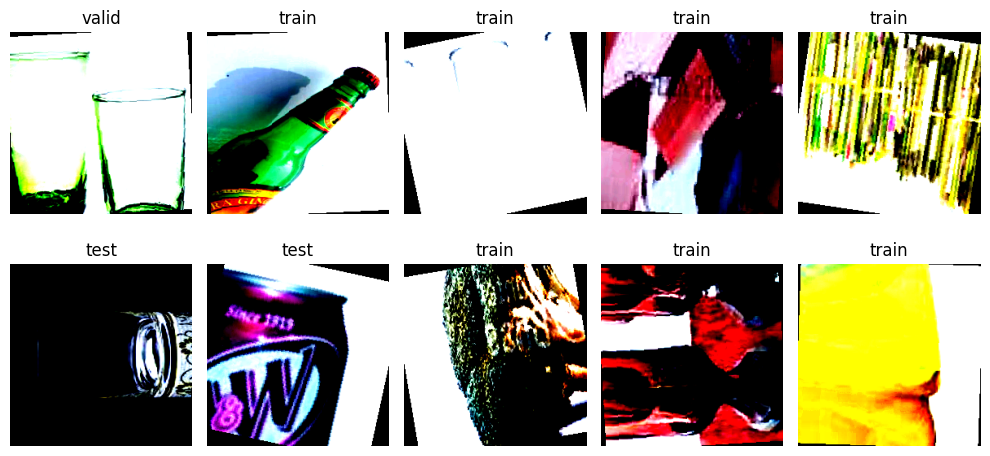

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import random
import kagglehub
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import ResNet18_Weights

# Download the dataset to ensure it's available.
# This makes the cell self-contained for dataset access.
path = kagglehub.dataset_download("hutinguynhunh/garbage-classification-v2")
print("Path to dataset files:", path)

# Original transforms and dataset definition, adapted from 'bRaVuFeg9_SH'
weights = ResNet18_Weights.DEFAULT
imagenet_mean = weights.meta.get("mean", (0.485, 0.456, 0.406))
imagenet_std = weights.meta.get("std", (0.229, 0.224, 0.225))

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

dataset = ImageFolder(root=path, transform=train_transforms)

plt.figure(figsize=(10, 5))

for i in range(10):
    idx = random.randint(0, len(dataset) - 1)
    img, label = dataset[idx]

    # Convert the tensor image to a numpy array for displaying
    img = img.permute(1, 2, 0).numpy()

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(dataset.classes[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#@markdown ## 2. Transforms + balanced dataloaders
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
from collections import Counter
from torchvision.models import ResNet18_Weights

weights = ResNet18_Weights.DEFAULT
imagenet_mean = weights.meta.get("mean", (0.485, 0.456, 0.406))
imagenet_std = weights.meta.get("std", (0.229, 0.224, 0.225))

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])
eval_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

dataset = ImageFolder(root=path, transform=train_transforms)
total = len(dataset)
train_len = int(0.8 * total)
test_len = total - train_len
train_dataset, test_dataset = random_split(dataset, [train_len, test_len])
test_dataset.dataset.transform = eval_transforms

train_targets = [dataset.samples[i][1] for i in train_dataset.indices]
class_counts = Counter(train_targets)
class_weights = {cls: 1.0 / cnt for cls, cnt in class_counts.items()}
sample_weights = [class_weights[target] for target in train_targets]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
#@markdown ## 3. Model + optimizer setup
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet18
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(dataset.classes)

model = resnet18(weights=weights)
for param in model.parameters():
    param.requires_grad = False
for param in model.layer4.parameters():
    param.requires_grad = True
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=20)
scaler = GradScaler()


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]
/tmp/ipykernel_10663/2167873726.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
#@markdown ## 4. Training loop with evaluation
def evaluate(loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

num_epochs = 15
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
    scheduler.step()
    val_acc = evaluate(test_loader)
    print(f"Epoch {epoch+1:02d} | train loss {running_loss/len(train_loader):.4f} | val acc {val_acc:.2f}%")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_10663/2894340428.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 01 | train loss 0.6937 | val acc 64.34%
Epoch 02 | train loss 0.3156 | val acc 74.34%
Epoch 03 | train loss 0.2031 | val acc 76.34%
Epoch 04 | train loss 0.1481 | val acc 78.07%
Epoch 05 | train loss 0.1180 | val acc 74.73%
Epoch 06 | train loss 0.0942 | val acc 79.44%
Epoch 07 | train loss 0.0823 | val acc 78.68%
Epoch 08 | train loss 0.0721 | val acc 77.60%
Epoch 09 | train loss 0.0699 | val acc 77.42%
Epoch 10 | train loss 0.0625 | val acc 80.51%
Epoch 11 | train loss 0.0498 | val acc 80.31%
Epoch 12 | train loss 0.0452 | val acc 81.05%
Epoch 13 | train loss 0.0378 | val acc 81.03%
Epoch 14 | train loss 0.0299 | val acc 80.77%
Epoch 15 | train loss 0.0305 | val acc 80.81%
